In [1]:
import numpy as np
import matplotlib.pyplot as plt
import models
import pandas as pd

In [2]:
df_iris = pd.read_csv(
'https://archive.ics.uci.edu/ml/'
'machine-learning-databases/iris/iris.data',
header=None, encoding='utf-8')

df_wine = pd.read_csv(
'https://archive.ics.uci.edu/ml/'
'machine-learning-databases/wine/wine.data',
header=None
)

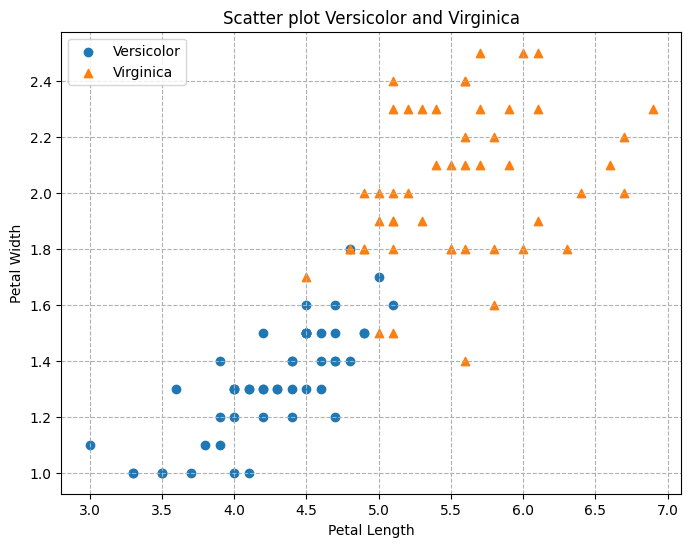

In [3]:
df_versicolor = df_iris[df_iris[4] == 'Iris-versicolor']
df_virginica = df_iris[df_iris[4] == 'Iris-virginica']

plt.figure(figsize=(8, 6))
plt.scatter(df_versicolor[2], df_versicolor[3], marker='o', label='Versicolor')

plt.scatter(df_virginica[2], df_virginica[3], marker='^', label='Virginica')

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Scatter plot Versicolor and Virginica')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--')
plt.show()

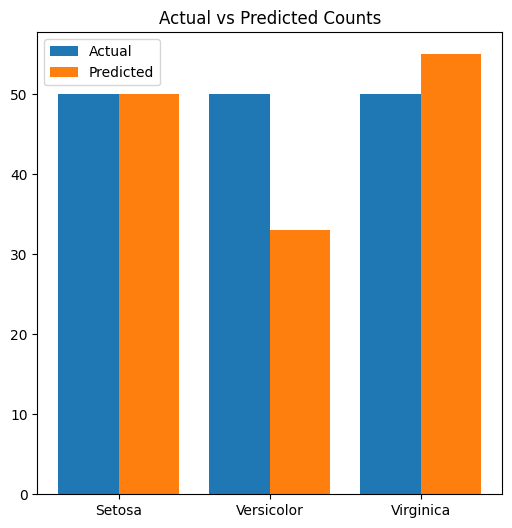

np.int64(129)

In [8]:
#  Question 3: Multi class classification using OvR strategy 
X = df_iris.iloc[:, 0:4].values
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = df_iris.iloc[:, 4].values
multi_model = models.MultiClassAdalineGD(models.AdalineGD, 0.05, 150)
multi_model.fit(X,y)
y_test = multi_model.predict(X)

# Predictions
classes = ['Setosa', 'Versicolor', 'Virginica']
actual_counts = [50, 50, 50]

sestosa = multi_model.models['Iris-setosa'].predict(X).sum()
versicolor = multi_model.models['Iris-versicolor'].predict(X).sum()
virginica = multi_model.models['Iris-virginica'].predict(X).sum()

predicted = [sestosa, versicolor, virginica]
plt.figure(figsize=(6, 6))
plt.bar(classes, actual_counts, width=-0.4, align='edge', label='Actual')
plt.bar(classes, predicted, width=0.4, align='edge', label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Counts")
plt.show()

(y == y_test).sum()



In [6]:
# Question 4: Comparing GD, SDS and mini-batch SHD
gd_model = models.LogisticRegressionGD(0.05, 150)
sgd_model = models.LogisticRegressionGD(0.05, 150, 1, True, 1)
msgd_model = models.LogisticRegressionGD(0.05, 150)
X = df_wine.iloc[0:130, 1:].values
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = df_wine.iloc[0:130, 0].values
y = np.where(y == 1, 1, 0)

time_gd = np.zeros(gd_model.n_iter)
time_sgd = np.zeros(sgd_model.n_iter)
time_msgd = np.zeros(msgd_model.n_iter)

loss_gd = np.zeros(gd_model.n_iter)
loss_sgd = np.zeros(sgd_model.n_iter)
loss_msgd = np.zeros(msgd_model.n_iter)

count = 5

for _ in range(count):
    gd_model.fit(X, y)
    sgd_model.fit_mini_batch_SGD(X, y)
    msgd_model.fit_mini_batch_SGD(X, y)

    time_gd = time_gd + np.array(gd_model.elasped_time)
    time_sgd = time_sgd + np.array(sgd_model.elasped_time)
    time_msgd = time_msgd + np.array(msgd_model.elasped_time)

    loss_gd = loss_gd + np.array(gd_model.losses_)
    loss_sgd = loss_sgd + np.array(sgd_model.losses_)
    loss_msgd = loss_msgd + np.array(msgd_model.losses_)

time_gd = time_gd / count
time_sgd = time_sgd / count
time_msgd = time_msgd / count

loss_gd = loss_gd / count
loss_sgd = loss_sgd / count
loss_msgd = loss_msgd / count


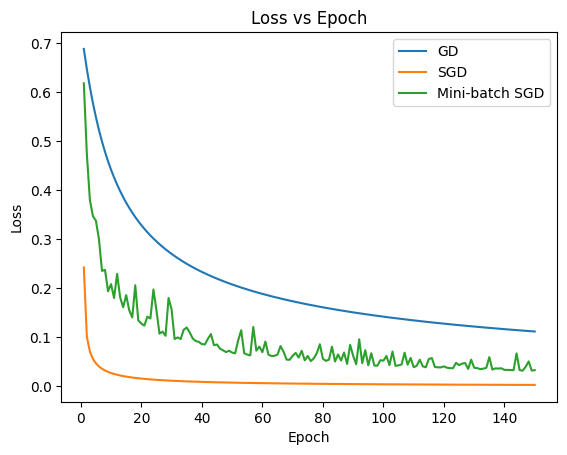

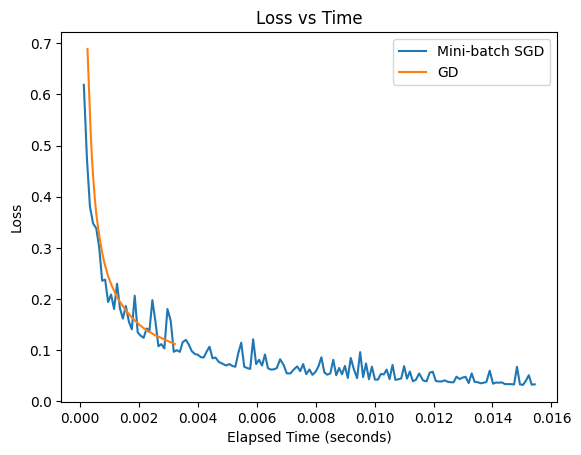

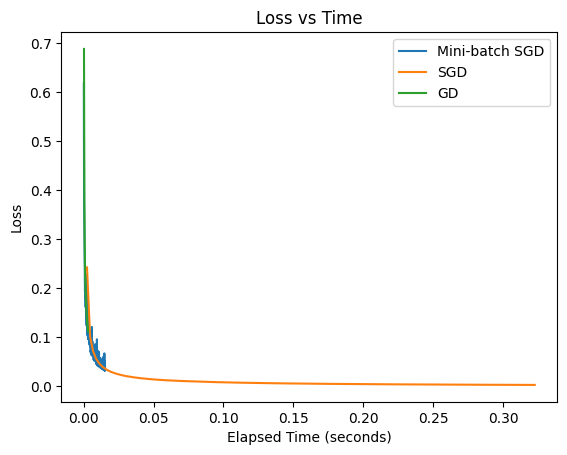

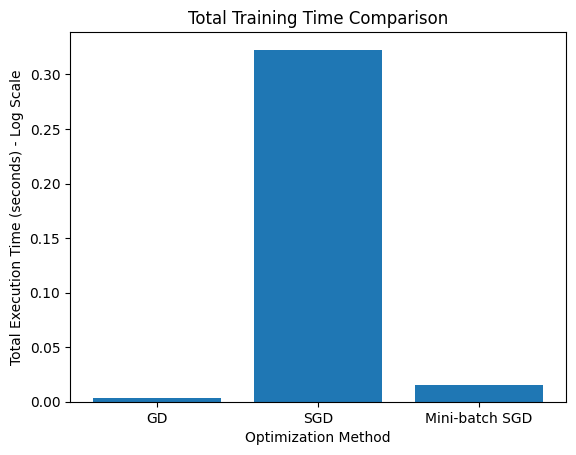

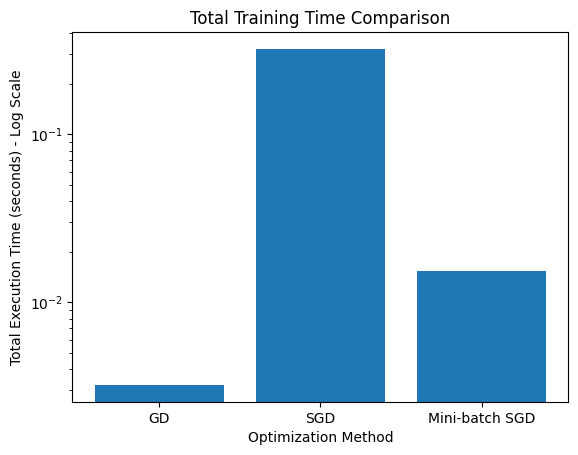

In [ ]:
plt.plot(range(1, gd_model.n_iter + 1), gd_model.losses_, label="GD")
plt.plot(range(1, sgd_model.n_iter + 1), sgd_model.losses_, label="SGD")
plt.plot(range(1, msgd_model.n_iter + 1), msgd_model.losses_, label="Mini-batch SGD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

plt.plot(time_msgd, msgd_model.losses_, label="Mini-batch SGD")
plt.plot(time_gd, gd_model.losses_, label="GD")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

plt.plot(time_msgd, msgd_model.losses_, label="Mini-batch SGD")
plt.plot(time_sgd, sgd_model.losses_, label="SGD")
plt.plot(time_gd, gd_model.losses_, label="GD")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.show()

total_time_gd = time_gd[-1]
total_time_sgd = time_sgd[-1]
total_time_msgd = time_msgd[-1]
plt.bar(['GD', 'SGD', 'Mini-batch SGD'], [total_time_gd, total_time_sgd, total_time_msgd])
plt.yscale('log')
plt.xlabel("Optimization Method")
plt.ylabel("Total Execution Time (seconds) - Log Scale")
plt.title("Total Training Time Comparison")
plt.show()